In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
data={
"Patient_ID":np.random.randint(1,10000,10000),
"Age":np.random.randint(20,80,10000),
"Gender":np.random.choice(["Male","Female"],10000),
"Blood_Pressure":np.random.randint(80,180,10000),
"Sugar_Level":np.random.randint(70,200,10000),
"Cholesterol":np.random.randint(150,300,10000),
"Heart_Rate":np.random.randint(60,120,10000)
}

In [17]:
df=pd.DataFrame(data)

In [18]:
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True),inplace=True)

In [19]:
def classify_risk(row):
    if(row["Blood_Pressure"]>140 or row["Sugar_Level"]>180 or row["Cholesterol"]>240 or row["Heart_Rate"]>100):return"High"
    elif(row["Blood_Pressure"]>120 or row["Sugar_Level"]>140 or row["Cholesterol"]>200):return"Medium"
    else:return"Low"

In [20]:
df["Risk_Level"]=df.apply(classify_risk,axis=1)

In [21]:
print(df.describe())
high_risk=df[df["Risk_Level"]=="High"]
print(len(high_risk))
print(df.groupby("Gender")["Blood_Pressure"].mean())
print(df.groupby("Risk_Level").size())

         Patient_ID           Age  Blood_Pressure   Sugar_Level   Cholesterol  \
count  10000.000000  10000.000000    10000.000000  10000.000000  10000.000000   
mean    4991.615400     49.521200      128.927600    134.319600    225.186500   
std     2876.755282     17.223095       28.998256     37.931263     43.453655   
min        3.000000     20.000000       80.000000     70.000000    150.000000   
25%     2508.500000     35.000000      104.000000    101.000000    187.000000   
50%     4963.000000     50.000000      129.000000    135.000000    225.500000   
75%     7451.250000     64.000000      154.000000    168.000000    263.000000   
max     9999.000000     79.000000      179.000000    199.000000    299.000000   

         Heart_Rate  
count  10000.000000  
mean      89.178800  
std       17.324054  
min       60.000000  
25%       74.000000  
50%       89.000000  
75%      104.000000  
max      119.000000  
7806
Gender
Female    128.667003
Male      129.182934
Name: Blood_Pressu

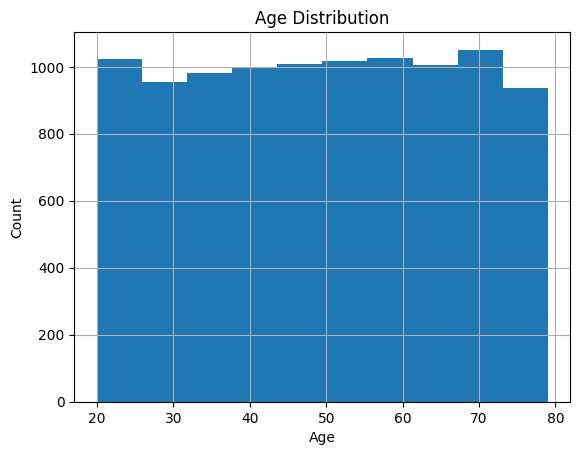

In [22]:
df["Age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

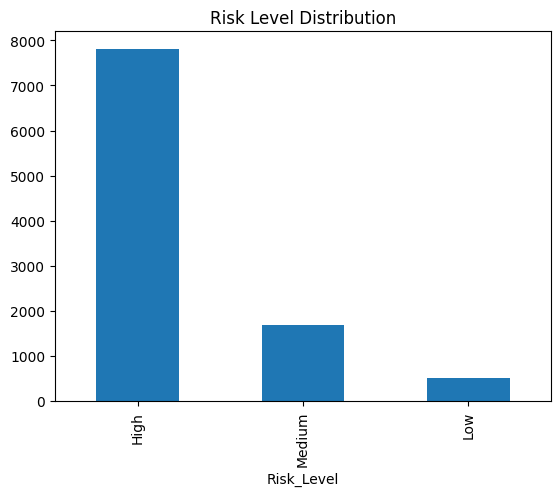

In [23]:
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()

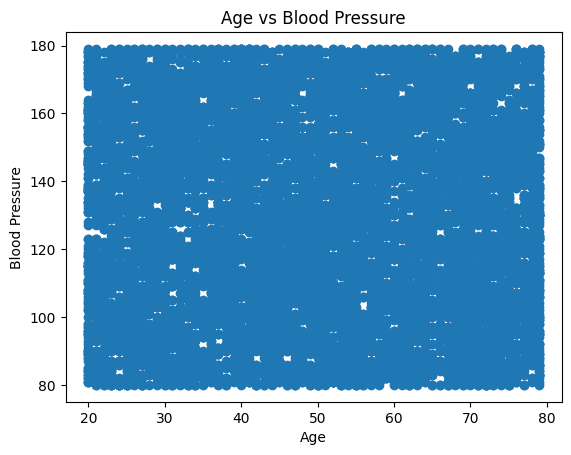

In [24]:
plt.scatter(df["Age"],df["Blood_Pressure"])
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Age vs Blood Pressure")
plt.show()

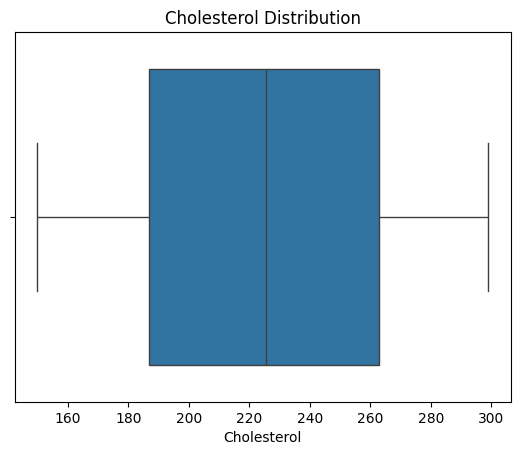

In [25]:
sns.boxplot(x=df["Cholesterol"])
plt.title("Cholesterol Distribution")
plt.show()

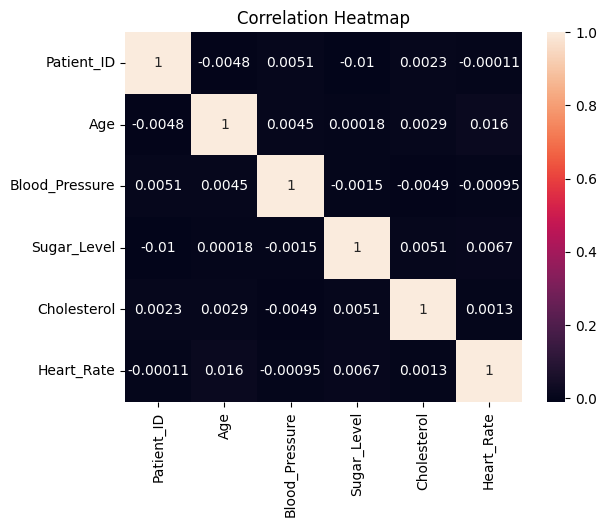

In [26]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()